In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import torch
import torch.nn as nn
from torchvision import models


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Linear(model.fc.in_features, 4)
model.load_state_dict(torch.load("/content/drive/MyDrive/Alzheimers /models/best_model.pt", map_location=device))
model = model.to(device)
model.eval()



Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 163MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [5]:
import pandas as pd

BASE = "/content/drive/MyDrive/Alzheimers /Datasets/MRI Dataset"

train_df = pd.read_parquet(f"{BASE}/train.parquet")
test_df  = pd.read_parquet(f"{BASE}/test.parquet")


In [6]:
import torchvision.transforms as transforms

IMG_SIZE = 224

test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [7]:
import io
from PIL import Image
from torch.utils.data import Dataset

class MRIDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_bytes = row["image"]["bytes"]
        img = Image.open(io.BytesIO(img_bytes)).convert("RGB")

        label = int(row["label"])

        if self.transform:
            img = self.transform(img)

        return img, label


In [8]:
test_ds = MRIDataset(test_df, transform=test_tfms)


In [9]:
from torch.utils.data import DataLoader

test_loader = DataLoader(
    test_ds,
    batch_size=16,
    shuffle=False   # 🔥 VERY IMPORTANT
)


In [10]:
imgs, labels = next(iter(test_loader))
imgs.shape, labels[:10]



(torch.Size([16, 3, 224, 224]), tensor([3, 0, 2, 3, 0, 3, 2, 2, 2, 3]))

In [11]:
import torch
import torch.nn as nn
from torchvision import models

device = "cuda" if torch.cuda.is_available() else "cpu"

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Linear(model.fc.in_features, 4)

model.load_state_dict(
    torch.load("/content/drive/MyDrive/Alzheimers /models/best_model.pt",
               map_location=device)
)

model = model.to(device)
model.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

all_labels = []
all_preds = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        y = y.to(device)

        outputs = model(x)
        preds = outputs.argmax(1)

        all_labels.extend(y.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

len(all_labels), len(all_preds)


(1280, 1280)

In [13]:
class_names = [
    "Non-Demented",
    "Very Mild Demented",
    "Mild Demented",
    "Moderate Demented"
]


In [14]:
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        digits=4
    )
)


                    precision    recall  f1-score   support

      Non-Demented     0.6122    0.1744    0.2715       172
Very Mild Demented     0.0000    0.0000    0.0000        15
     Mild Demented     0.6891    0.6609    0.6747       634
 Moderate Demented     0.4799    0.6514    0.5527       459

          accuracy                         0.5844      1280
         macro avg     0.4453    0.3717    0.3747      1280
      weighted avg     0.5957    0.5844    0.5689      1280



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [16]:
import os

BASE = "/content/drive/MyDrive/Alzheimers "
OUTPUTS = f"{BASE}/outputs"

os.makedirs(OUTPUTS, exist_ok=True)

OUTPUTS


'/content/drive/MyDrive/Alzheimers /outputs'

In [17]:
plt.savefig(f"{OUTPUTS}/confusion_matrix.png", dpi=200)
plt.show()


<Figure size 640x480 with 0 Axes>

In [18]:
os.listdir("/content/drive/MyDrive")


['Photo.docx',
 'IMG_20200805_111337_120.jpg',
 'IMG_20200805_111342_721.jpg',
 'VID_123140214_071249_589.mp4',
 'P1050501.JPG',
 'P1050502.JPG',
 'bhuvan-signature.pdf',
 'bhuvan-pic.pdf',
 '1651395533218.jpg',
 '1651395718865.jpg',
 '1651396103775.jpg',
 '1651396431949.jpg',
 'comedk application.pptx',
 'cetpayment.pptx',
 '1651480863869 (1) (1).jpg',
 'TEST ADMISSION TICKET.pdf',
 'keaapplicationpd_5020207181721_02062022_232553.pdf',
 'CUK0055076.pdf',
 '802996.k.pdf',
 '802996.m.pdf',
 '~..',
 'IMG20220722140620 (1).jpg',
 'IMG20220722140620.jpg',
 'IMG20220722140620.pdf',
 'OpTransactionHistory22-07-2022.pdf',
 'Quiz.pptx',
 'Bank statement.pdf',
 'A6W6Y3JhoI3YGjIm-953.pdf',
 'YourPayslip_June2022.pdf',
 '10th .pdf',
 'hcJee70CgbcGjEia-104.pdf',
 '1lZfB0R8UKfeMdZo-384.pdf',
 '6BBTaV1nCoQal2dO-303.pdf',
 'income_caste_bhu.pdf',
 'IMG20220722162853.pdf',
 'ganesha habba_22',
 'Document from Bhuvan A',
 'Classroom',
 'Bhuvan.A_22-0580',
 'Untitled spreadsheet.gsheet',
 's_kan QBANK_1

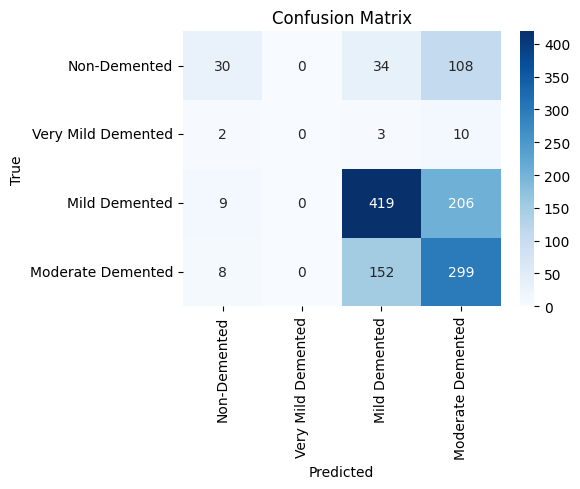

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()

plt.savefig("/content/drive/MyDrive/Alzheimers /outputs/confusion_matrix.png", dpi=200)
plt.show()


In [20]:
import os
BASE = "/content/drive/MyDrive/Alzheimers "
GRADCAM_DIR = f"{BASE}/outputs/gradcam"
os.makedirs(GRADCAM_DIR, exist_ok=True)


In [21]:
import torch
import torch.nn as nn
from torchvision import models

device = "cuda" if torch.cuda.is_available() else "cpu"

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Linear(model.fc.in_features, 4)

model.load_state_dict(
    torch.load("/content/drive/MyDrive/Alzheimers /models/best_model.pt",
               map_location=device)
)

model = model.to(device)
model.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [22]:
import torch.nn.functional as F

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, x, index=None):
        output = self.model(x)

        if index is None:
            index = output.argmax(dim=1)

        loss = output[:, index]
        self.model.zero_grad()
        loss.backward(retain_graph=True)

        weights = self.gradients.mean(dim=(2,3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1)

        cam = F.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam, output


In [23]:
target_layer = model.layer4[-1]
cam = GradCAM(model, target_layer)


In [24]:
samples = []

with torch.no_grad():
    for x,y in test_loader:
        for img,label in zip(x,y):
            if len(samples) < 12:
                samples.append((img, int(label)))
        if len(samples) >= 12:
            break


In [25]:
import torchvision.transforms as transforms
import numpy as np

inv_norm = transforms.Normalize(
    mean=[-m/s for m,s in zip([0.485,0.456,0.406],[0.229,0.224,0.225])],
    std=[1/s for s in [0.229,0.224,0.225]]
)


In [26]:
import matplotlib.pyplot as plt
import cv2

for i,(img,label) in enumerate(samples):

    x = img.unsqueeze(0).to(device)

    heatmap, output = cam(x)
    pred = output.argmax(1).item()

    heatmap = heatmap[0].cpu().numpy()
    heatmap = cv2.resize(heatmap, (224,224))
    heatmap = (255*heatmap).astype(np.uint8)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    img_disp = inv_norm(img).permute(1,2,0).numpy()
    img_disp = np.clip(img_disp,0,1)
    img_disp = (img_disp*255).astype(np.uint8)

    overlay = cv2.addWeighted(img_disp, 0.5, heatmap, 0.5, 0)

    plt.figure(figsize=(9,3))

    plt.subplot(1,3,1)
    plt.imshow(img_disp)
    plt.title(f"Original\nTrue: {class_names[label]}")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(heatmap[:,:,::-1])
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(overlay[:,:,::-1])
    plt.title(f"Overlay\nPred: {class_names[pred]}")
    plt.axis("off")

    plt.tight_layout()
    plt.savefig(f"{GRADCAM_DIR}/gradcam_{i}.png", dpi=220)
    plt.close()


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1866: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)
